# Why Should We Trust This Model?
## Notebook 3: Explaining Every Prediction with SHAP

**Author:** Agatha Ulina Silalahi  
**Objective:** Make the XGBoost model explainable — not just to data scientists, but to credit analysts and business stakeholders.

> *"A model that can't explain its decisions won't survive its first credit committee meeting."*

### What is SHAP?
SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for every 
individual prediction. Unlike feature importance (global average), SHAP tells us:
- **Why** a specific applicant was flagged as high risk
- **Which features** pushed the risk up vs. down
- **How much** each feature contributed, in comparable units

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'default': '#E63946', 'no_default': '#457B9D', 'accent': '#F4A261'}

# Initialize SHAP JS untuk notebook rendering
shap.initjs()

print("✅ Libraries loaded")
print(f"SHAP version: {shap.__version__}")

✅ Libraries loaded
SHAP version: 0.51.0


## Load Model and Data

In [2]:
# Load model yang disimpan di Notebook 2
xgb_model = joblib.load('../models/xgb_credit_default.pkl')
imputer   = joblib.load('../models/imputer.pkl')

# Load dan re-process data (sama persis dengan Notebook 2)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/application_train.csv')

# Feature engineering
df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_GOODS_RATIO']    = df['AMT_CREDIT']  / (df['AMT_GOODS_PRICE'] + 1)
df['AGE_YEARS']             = abs(df['DAYS_BIRTH']) / 365
df['EMPLOYMENT_YEARS']      = abs(df['DAYS_EMPLOYED'].clip(upper=0)) / 365
df['INCOME_PER_PERSON']     = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df['ANNUITY_CREDIT_RATIO']  = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)

# Drop high-missing features
missing_pct  = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.4].index.tolist()
df           = df.drop(columns=cols_to_drop)

# Encode
le       = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_imp = pd.DataFrame(imputer.transform(X), columns=X.columns)

_, X_test, _, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Test set: {X_test.shape}")
print(f"Default rate in test: {y_test.mean()*100:.2f}%")

Test set: (61503, 78)
Default rate in test: 8.07%


## Hitung SHAP Values

In [4]:
print("Computing SHAP values ...")

# TreeExplainer — dioptimalkan khusus untuk XGBoost/tree models
explainer   = shap.TreeExplainer(xgb_model)

# Pakai sample 2000 untuk speed — tetap representatif
sample_idx  = X_test.sample(2000, random_state=42).index
X_sample    = X_test.loc[sample_idx].reset_index(drop=True)
y_sample    = y_test.loc[sample_idx].reset_index(drop=True)

shap_values = explainer.shap_values(X_sample)

print(f"✅ SHAP values computed")
print(f"Shape: {shap_values.shape}  → (samples × features)")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")

Computing SHAP values ...
✅ SHAP values computed
Shape: (2000, 78)  → (samples × features)
Expected value (base rate): 0.0191


## Global Feature Importance (Summary Plot)

Generating Summary Plot...


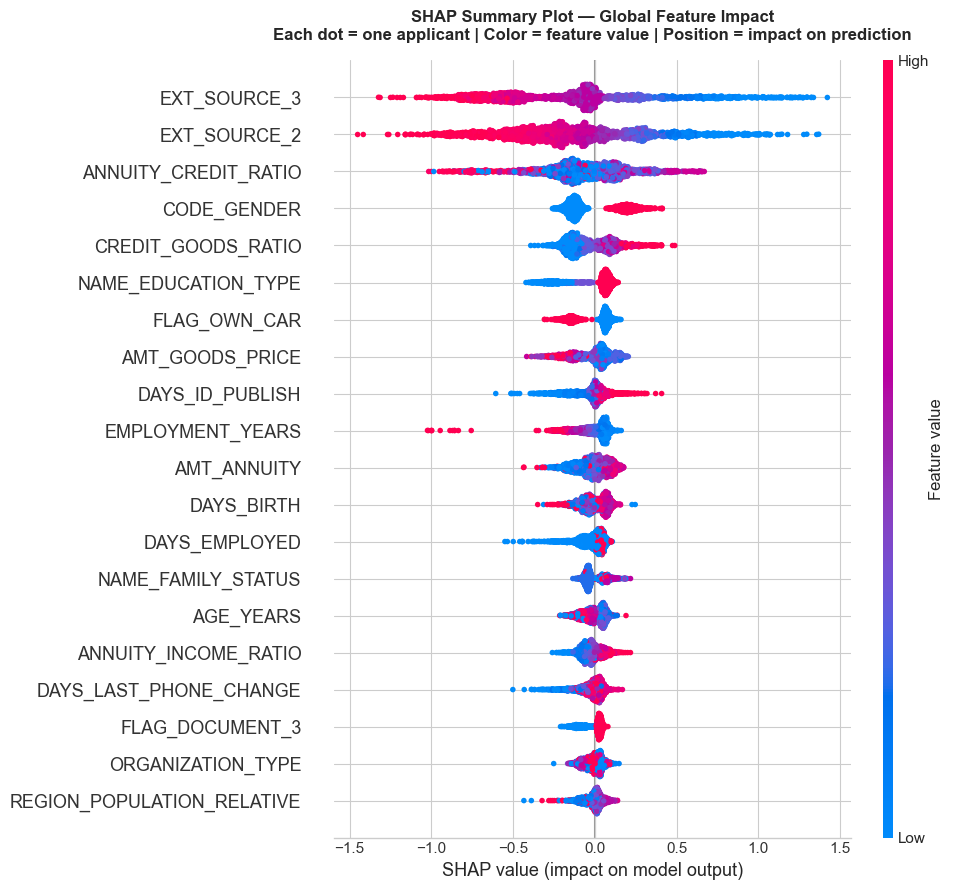


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #4 — What Actually Drives Default Risk
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
How to read this chart:
- Red dots = high feature value, Blue dots = low
- Right side = pushes toward DEFAULT
- Left side = pushes toward NO DEFAULT

Key insight: EXT_SOURCE scores are strongly 
protective (high score = low default risk).
Employment duration and age are also protective.
High credit-to-income ratio increases risk.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [5]:
print("Generating Summary Plot...")

plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display = 20,
    show        = False,
    plot_size   = None
)
plt.title('SHAP Summary Plot — Global Feature Impact\n'
          'Each dot = one applicant | Color = feature value | '
          'Position = impact on prediction',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/10_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #4 — What Actually Drives Default Risk
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
How to read this chart:
- Red dots = high feature value, Blue dots = low
- Right side = pushes toward DEFAULT
- Left side = pushes toward NO DEFAULT

Key insight: EXT_SOURCE scores are strongly 
protective (high score = low default risk).
Employment duration and age are also protective.
High credit-to-income ratio increases risk.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

## Bar Plot: Mean Absolute SHAP

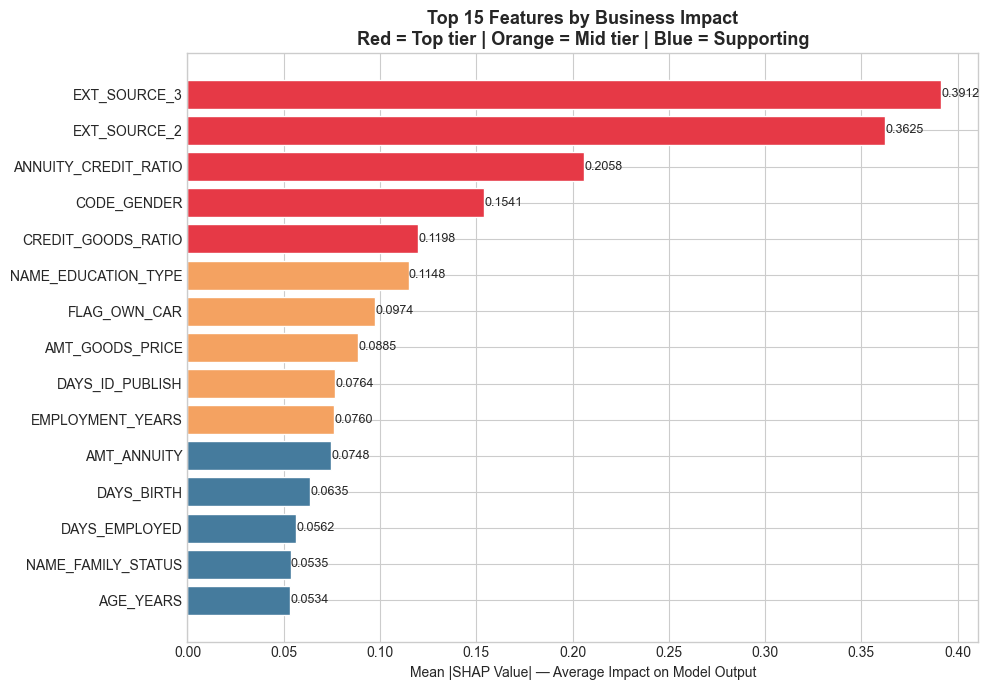

In [6]:
shap_df = pd.DataFrame(shap_values, columns=X_sample.columns)
mean_abs = shap_df.abs().mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = [COLORS['default'] if i < 5 else COLORS['accent'] if i < 10
           else COLORS['no_default'] for i in range(len(mean_abs))]
bars    = ax.barh(mean_abs.index[::-1], mean_abs.values[::-1],
                  color=colors[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP Value| — Average Impact on Model Output')
ax.set_title('Top 15 Features by Business Impact\n'
             'Red = Top tier | Orange = Mid tier | Blue = Supporting',
             fontweight='bold', fontsize=13)
for bar, val in zip(bars, mean_abs.values[::-1]):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/11_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Waterfall Plot: Satu Nasabah Berisiko Tinggi

Applicant #1035
Predicted risk probability : 93.5%
Actual outcome             : DEFAULT ❌


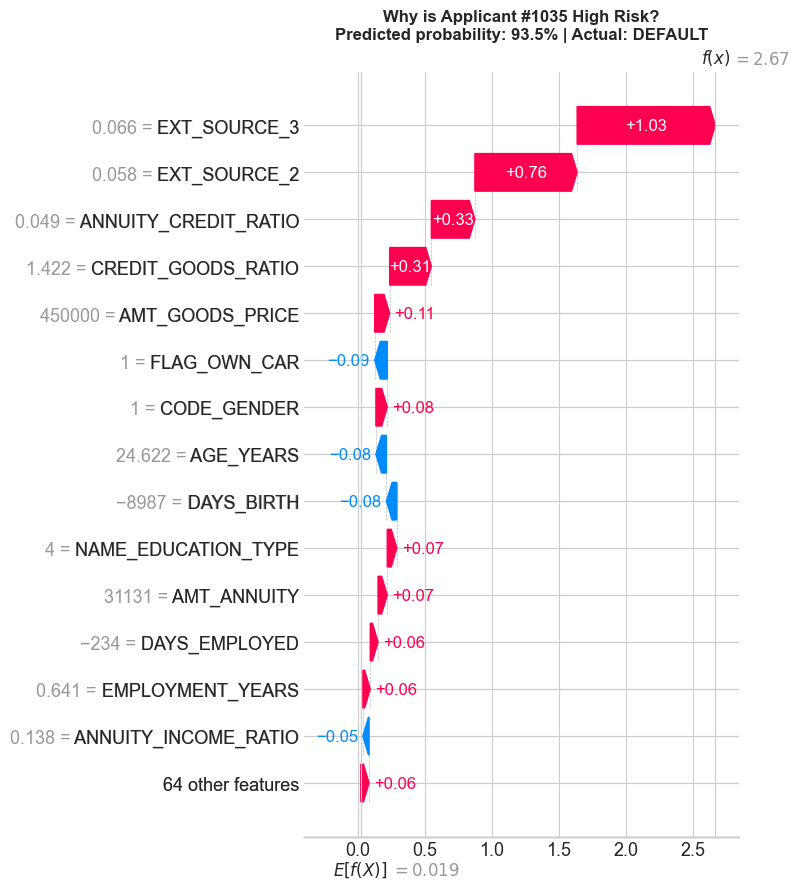

In [7]:
# Cari nasabah dengan predicted probability tertinggi (paling berisiko)
proba_sample = xgb_model.predict_proba(X_sample)[:, 1]
high_risk_idx = np.argmax(proba_sample)
high_risk_prob = proba_sample[high_risk_idx]
high_risk_true = y_sample.iloc[high_risk_idx]

print(f"Applicant #{high_risk_idx}")
print(f"Predicted risk probability : {high_risk_prob:.1%}")
print(f"Actual outcome             : {'DEFAULT ❌' if high_risk_true == 1 else 'NO DEFAULT ✅'}")

# Waterfall plot
explanation = shap.Explanation(
    values    = shap_values[high_risk_idx],
    base_values = explainer.expected_value,
    data      = X_sample.iloc[high_risk_idx],
    feature_names = X_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(f'Why is Applicant #{high_risk_idx} High Risk?\n'
          f'Predicted probability: {high_risk_prob:.1%} | '
          f'Actual: {"DEFAULT" if high_risk_true==1 else "NO DEFAULT"}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/12_shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()

## Dependence Plot: EXT_SOURCE_3

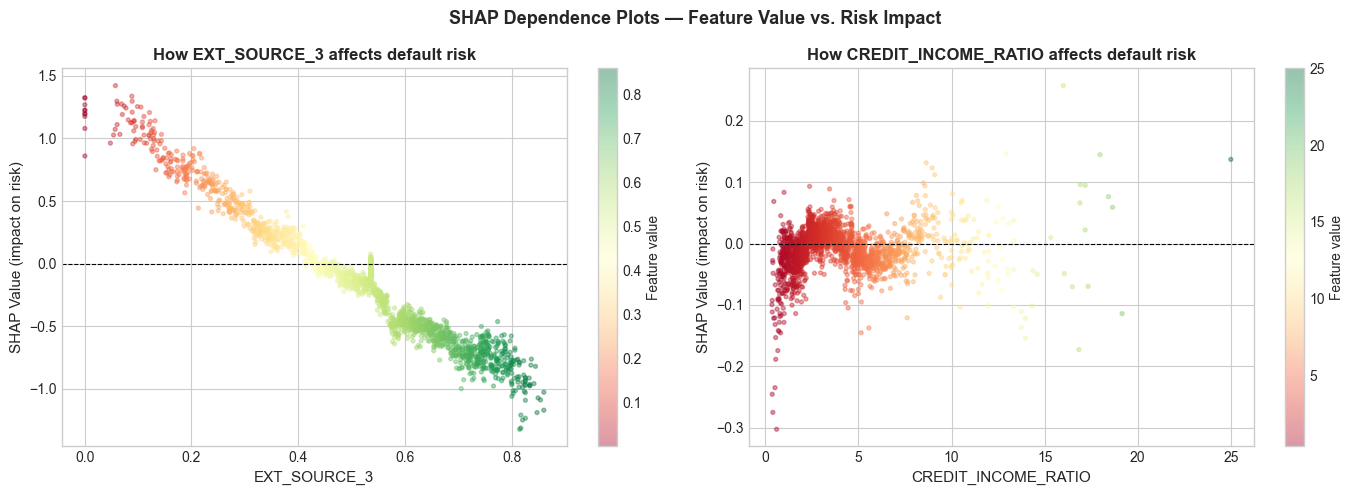

In [8]:
# Lihat hubungan antara EXT_SOURCE_3 dan risk — fitur terpenting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ['EXT_SOURCE_3', 'CREDIT_INCOME_RATIO']):
    if feat not in X_sample.columns:
        continue
    feat_idx   = X_sample.columns.tolist().index(feat)
    feat_vals  = X_sample[feat].values
    shap_vals  = shap_values[:, feat_idx]

    sc = ax.scatter(feat_vals, shap_vals,
                    c=feat_vals, cmap='RdYlGn',
                    alpha=0.4, s=8)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('SHAP Value (impact on risk)', fontsize=11)
    ax.set_title(f'How {feat} affects default risk',
                 fontweight='bold', fontsize=12)
    plt.colorbar(sc, ax=ax, label='Feature value')

plt.suptitle('SHAP Dependence Plots — Feature Value vs. Risk Impact',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/14_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# 3 Risk Persona

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 FINDING #5 — Three Distinct Risk Personas
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
               count  avg_prob  actual_default  avg_age  avg_credit_income  avg_employment
risk_tier                                                                                 
🟢 Low Risk       902     0.177           0.020   47.476              4.067           6.387
🟡 Medium Risk    774     0.437           0.103   42.870              4.018           4.729
🔴 High Risk      324     0.712           0.219   38.705              3.801           3.953
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


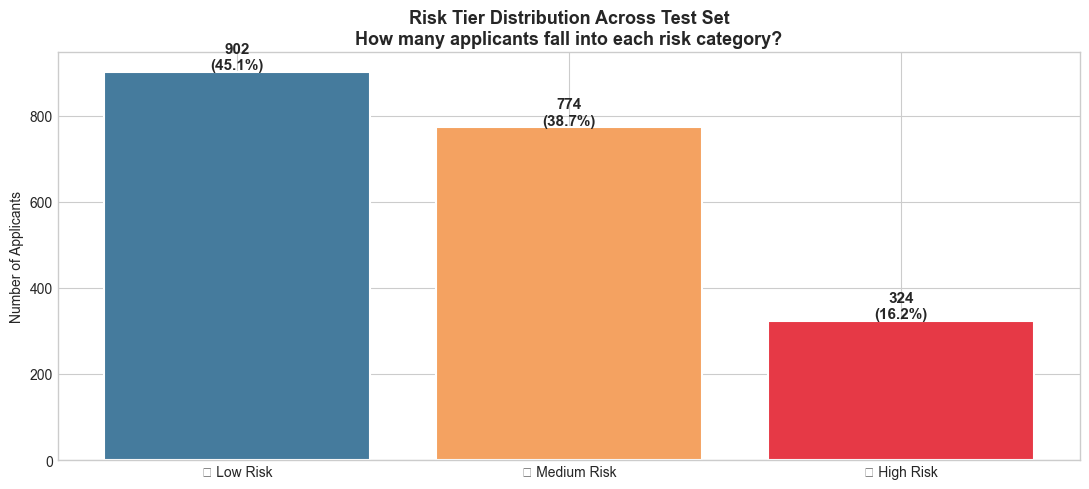

In [9]:
# Buat risk score per applicant
proba_all  = xgb_model.predict_proba(X_sample)[:, 1]
risk_df    = X_sample.copy()
risk_df['risk_score']  = proba_all
risk_df['true_label']  = y_sample.values

# Segmentasi ke 3 tier
risk_df['risk_tier'] = pd.cut(
    risk_df['risk_score'],
    bins   = [0, 0.3, 0.6, 1.0],
    labels = ['🟢 Low Risk', '🟡 Medium Risk', '🔴 High Risk']
)

tier_summary = risk_df.groupby('risk_tier', observed=True).agg(
    count        = ('risk_score', 'count'),
    avg_prob     = ('risk_score', 'mean'),
    actual_default = ('true_label', 'mean'),
    avg_age      = ('AGE_YEARS', 'mean'),
    avg_credit_income = ('CREDIT_INCOME_RATIO', 'mean'),
    avg_employment = ('EMPLOYMENT_YEARS', 'mean')
).round(3)

print("━"*65)
print("📌 FINDING #5 — Three Distinct Risk Personas")
print("━"*65)
print(tier_summary.to_string())
print("━"*65)

# Visualisasi distribusi
fig, ax = plt.subplots(figsize=(11, 5))
colors_tier = [COLORS['no_default'], COLORS['accent'], COLORS['default']]
tier_counts = risk_df['risk_tier'].value_counts().sort_index()
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=colors_tier, edgecolor='white', linewidth=1.5)
ax.set_title('Risk Tier Distribution Across Test Set\n'
             'How many applicants fall into each risk category?',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Applicants')
for bar, val in zip(bars, tier_counts.values):
    pct = val / len(risk_df) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/15_risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

## Persona Narrative (Opini Bisnis)

In [12]:
reports = [
    '10_shap_summary.png',
    '11_shap_bar.png',
    '12_shap_waterfall_highrisk.png',
    '13_shap_waterfall_lowrisk.png',
    '14_shap_dependence.png',
    '15_risk_tiers.png'
]

print("━"*55)
print("✅ NOTEBOOK 3 COMPLETE — SHAP Explainability")
print("━"*55)
print(f"\nReports generated ({len(reports)} charts):")
for r in reports:
    print(f"  → reports/{r}")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROJECT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Notebook 1 ✅  EDA — 6 charts, 5 business findings
Notebook 2 ✅  Modeling — XGBoost beats LR & RF
Notebook 3 ✅  SHAP — every prediction explained

Total charts : 15
Total reports: reports/
Model saved  : models/xgb_credit_default.pkl
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ NOTEBOOK 3 COMPLETE — SHAP Explainability
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Reports generated (6 charts):
  → reports/10_shap_summary.png
  → reports/11_shap_bar.png
  → reports/12_shap_waterfall_highrisk.png
  → reports/13_shap_waterfall_lowrisk.png
  → reports/14_shap_dependence.png
  → reports/15_risk_tiers.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROJECT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Notebook 1 ✅  EDA — 6 charts, 5 business findings
Notebook 2 ✅  Modeling — XGBoost beats LR & RF
Notebook 3 ✅  SHAP — every prediction explained

Total charts : 15
Total reports: reports/
Model saved  : models/xgb_credit_default.pkl
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

